In [16]:
import pandas as pd

import plotly.express as px

dfs = []
for i in range(2, 9):
    df = pd.read_json(f'../results/quest/gloo_{i}.json')
    df['source'] = i
    df['hops'] = i - 1
    df['true_size_bytes'] = df['size_bytes'] * (i - 1)
    dfs.append(df)

# Concatenate DataFrames
df = pd.concat(dfs)

In [17]:
# Aggregate data by mean time_s for each size_bytes and source
df_agg = df.groupby(['true_size_bytes', 'source'])['time_s'].mean().reset_index()

# Create the plot
fig = px.line(df_agg, x='true_size_bytes', y='time_s', color='source', title='Bytes over Time (Mean)')
fig.show()

In [18]:
import pandas as pd
import statsmodels.api as sm

# df with columns: size_bytes, source, hops, time_s
df = df.copy()
df["p_minus_1"] = df["source"] - 1
df["bytes_term"] = df["p_minus_1"] * df["size_bytes"]

X = df[["p_minus_1", "bytes_term"]]  # drop "hops" if it's constant/noisy
# X = sm.add_constant(X)  # include intercept if you want to absorb fixed overheads
y = df["time_s"]

model = sm.OLS(y, X).fit()
print(model.summary())

alpha = model.params["p_minus_1"]         # seconds per step
inv_B = model.params["bytes_term"]        # seconds per byte
B_eff = 1.0 / inv_B                       # bytes per second
delta = model.params.get("hops", 0.0)

                                 OLS Regression Results                                
Dep. Variable:                 time_s   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          3.070e+05
Date:                Fri, 17 Oct 2025   Prob (F-statistic):                        0.00
Time:                        17:59:56   Log-Likelihood:                          1111.1
No. Observations:                1260   AIC:                                     -2218.
Df Residuals:                    1258   BIC:                                     -2208.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

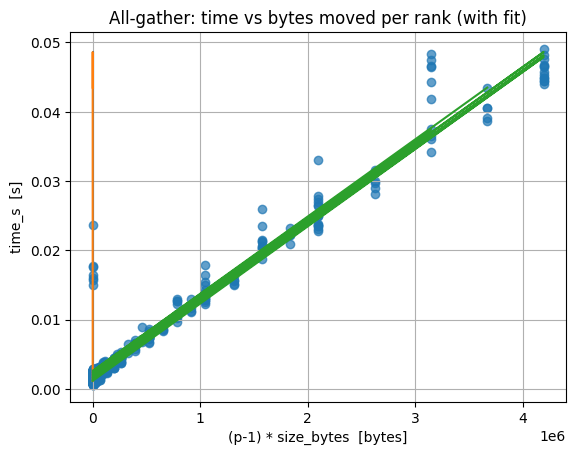

                            OLS Regression Results                            
Dep. Variable:                 time_s   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     8289.
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        17:59:56   Log-Likelihood:                 3537.7
No. Observations:                 733   AIC:                            -7069.
Df Residuals:                     730   BIC:                            -7056.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      5.858      0.0

In [19]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = df.copy()
df = df[df["time_s"] < 0.05]
df["p_minus_1"] = df["source"] - 1
df["bytes_term"] = df["p_minus_1"] * df["size_bytes"]

X = sm.add_constant(df[["p_minus_1", "bytes_term"]])
y = df["time_s"]
m = sm.OLS(y, X).fit()

# Predictions on sorted x for a clean line
xs = np.linspace(df["bytes_term"].min(), df["bytes_term"].max(), 100)
xp = np.linspace(df["p_minus_1"].min(), df["p_minus_1"].max(), 100)
Xline = sm.add_constant(pd.DataFrame({"bytes_term": xs, "p_minus_1": xp}))
yhat = m.predict(X)

plt.figure()
plt.scatter(df["bytes_term"], df["time_s"], alpha=0.7)
plt.plot(X, yhat)
plt.xlabel("(p-1) * size_bytes  [bytes]")
plt.ylabel("time_s  [s]")
plt.title("All-gather: time vs bytes moved per rank (with fit)")
plt.grid(True)
plt.show()

print(m.summary())


In [20]:
import pandas as pd
import statsmodels.api as sm
import json

with open('../results/.json', 'r') as f:
    orin_rtp_4_data = json.load(f)

# Assuming orin_rtp_4_data is a list of dicts with keys: total_transmit_duration, total_transmit_size, transmit_count
df_orin = pd.DataFrame(orin_rtp_4_data)

# Rename columns for consistency
df_orin['transmit_count'] = df_orin['transmit_count']
df_orin['time_s'] = df_orin['total_transmit_duration']
df_orin['bytes_term'] = df_orin['total_transmit_size'] * 3

# Use the model from CELL INDEX: 3 to predict
X_orin = sm.add_constant(df_orin[['bytes_term']])
# y_pred = m.predict(X_orin)
# y_pred = y_pred + df_orin['transmit_count'] * 0.0005 - 0.0211
y_pred = df_orin['transmit_count'] * 0.0006 + df_orin['bytes_term'] * 5.184e-09

# Compare predictions to actual
df_orin['predicted_time_s'] = y_pred
df_orin['error'] = df_orin['time_s'] - df_orin['predicted_time_s']
df_orin['abs_error'] = df_orin['error'].abs()

print("Predictions and errors:")
print(df_orin[['time_s', 'predicted_time_s', 'error', 'abs_error']])
print(f"Mean Absolute Error: {df_orin['abs_error'].mean()}")
print(f"Mean Percentage Error: {(df_orin['abs_error'] / df_orin['time_s']).mean() * 100:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: '../results/.json'